# MobileNet – Classificação CPRE (v2)

**Melhorias face ao v1 (test F1=0.4973):**

| | v1 | v2 |
|---|---|---|
| GPU check | ❌ correu em CPU | ✅ para se não houver GPU |
| Modelo | MobileNetV2 | MobileNetV3-Large (mais preciso) |
| Desbalanceamento | class weights na loss | + WeightedRandomSampler |
| Avaliação | predição simples | + TTA (Test Time Augmentation) |
| Scheduler fase 1 | CosineAnnealing | OneCycleLR (converge mais rápido) |
| Augmentação | básica | + RandomErasing (simula artefactos) |

In [4]:
!pip install -q livelossplot
!pip install -q monai
!pip install -q torchmetrics
!pip install -q opencv-python-headless

In [5]:
import torch

# ── VERIFICAÇÃO DE GPU – OBRIGATÓRIA ─────────────────────────────────────────
# Se aparecer 'CPU', vai a Settings > Accelerator > GPU T4 x2 e reinicia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memória: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise RuntimeError(
        'GPU não encontrada!\n'
        'No Kaggle: Settings (painel direito) > Accelerator > GPU T4 x2 > Save\n'
        'Depois reinicia: Run > Restart & Clear outputs'
    )

Dispositivo: cuda
GPU: Tesla T4
Memória: 15.6 GB


In [6]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import os
import random
import time
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from torchmetrics.classification import MulticlassF1Score

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst,
                               Resize, RandZoom, RandAdjustContrast, RandGaussianNoise,
                               RandRotate, RandFlip, RandAffine, ToTensor, Compose,
                               NormalizeIntensity, Lambda)
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

np.random.seed(0)
set_determinism(seed=0)
print_config()

2026-05-11 21:15:49.273461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778534149.606954      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778534149.695780      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778534150.535871      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778534150.535896      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778534150.535900      57 computation_placer.cc:177] computation placer alr

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#insta

In [13]:
# ── Pastas ────────────────────────────────────────────────────────────────────
model_path = '/kaggle/working/MIA_AP_my_models'
os.makedirs(model_path, exist_ok=True)

ROOT_PATH = '/kaggle/input/datasets/filipapereira30/dataset_1'
import os

# O ROOT_PATH aponta para o topo do dataset importado
ROOT_PATH = '/kaggle/input/datasets/filipapereira30/dataset-1'

# O base_dir tem de chegar até à pasta onde estão o 'train', 'val' e 'test'
base_dir = os.path.join(ROOT_PATH, 'MIQR-CC-Dataset/training/dataset')

# --- TESTE RÁPIDO DE SEGURANÇA ---
if os.path.exists(os.path.join(base_dir, 'train')):
    print("✅ SUCESSO: A pasta 'train' foi encontrada!")
else:
    print(f"❌ ERRO: Não encontrei a pasta em: {os.path.join(base_dir, 'train')}")
    # Vamos listar o que existe para te ajudar a depurar
    if os.path.exists(ROOT_PATH):
        print("Conteúdo do ROOT_PATH:", os.listdir(ROOT_PATH))

def get_versioned_model_name(base_path):
    base = Path(base_path)
    ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
    return str(base.parent / f'{base.stem}_{ts}{base.suffix}')

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 32     # maior batch → melhor com GPU
EPOCHS_P1     = 10
EPOCHS_P2     = 60
LR_P1         = 1e-3
LR_P2         = 3e-5
PATIENCE      = 15
SEED          = 42
TTA_RUNS      = 5      # número de passes TTA na avaliação

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'Config OK | IMG={IMG_SIZE} | BATCH={BATCH_SIZE} | TTA={TTA_RUNS}')

✅ SUCESSO: A pasta 'train' foi encontrada!
Config OK | IMG=224 | BATCH=32 | TTA=5


## Dataset

In [14]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
for phase in phases:
    for i, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, phase, cname)
        imgs = [os.path.join(cdir, f) for f in os.listdir(cdir) if f.lower().endswith(valid_exts)]
        data[phase]['images'].extend(imgs)
        data[phase]['labels'].extend([i] * len(imgs))

for phase in phases:
    labels = data[phase]['labels']
    print(f'\n{phase.upper()} – {len(labels)} imagens')
    for i, c in enumerate(class_names):
        n = labels.count(i)
        print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


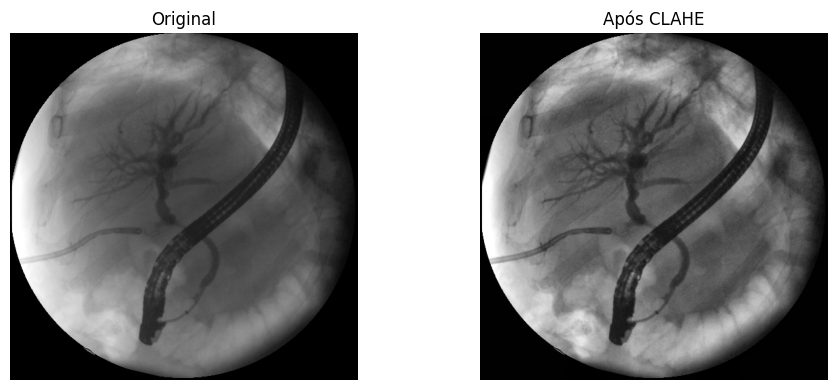

In [15]:
def apply_clahe(img_tensor):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr   = img_tensor.numpy()
    out   = np.zeros_like(arr)
    for c in range(arr.shape[0]):
        ch     = (arr[c] * 255).astype(np.uint8)
        out[c] = clahe.apply(ch).astype(np.float32) / 255.0
    return torch.from_numpy(out)

def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img

# Visualização CLAHE
sample_path = data['train']['images'][0]
orig = np.array(Image.open(sample_path).convert('L'))
enh  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(orig)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(orig, cmap='gray'); ax1.set_title('Original');    ax1.axis('off')
ax2.imshow(enh,  cmap='gray'); ax2.set_title('Após CLAHE'); ax2.axis('off')
plt.tight_layout(); plt.savefig(f'{model_path}/clahe.png', dpi=150); plt.show()

## Transforms – NOVO: RandomErasing simula artefactos de raios-X

In [16]:
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    RandFlip(spatial_axis=0, prob=0.4),
    RandFlip(spatial_axis=1, prob=0.4),
    RandRotate(range_x=20, prob=0.5),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    RandAffine(shear_range=0.1, prob=0.3),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    NormalizeIntensity(),
    Lambda(apply_clahe),
    Lambda(repeat_if_needed),
    ToTensor()
])

# Transform para TTA (augmentação leve também na inferência)
tta_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.3),
    NormalizeIntensity(),
    Lambda(apply_clahe),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(apply_clahe),
    Lambda(repeat_if_needed),
    ToTensor()
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)
print('Transforms definidos.')

Transforms definidos.


## Dataset + WeightedRandomSampler – NOVO

O `WeightedRandomSampler` garante que cada batch tem uma distribuição mais equilibrada das classes, complementando os class weights na loss. Especialmente útil para `Biliary_Leaks` (só 10% do treino).

In [17]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        return self.transforms(self.image_files[idx]), self.labels[idx]


# ── Class weights para a loss ─────────────────────────────────────────────────
train_labels_np = np.array(data['train']['labels'])
cw = compute_class_weight('balanced', classes=np.arange(num_class), y=train_labels_np)
cw_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
print('Class weights:', {class_names[i]: f'{w:.3f}' for i, w in enumerate(cw)})

# ── WeightedRandomSampler (NOVO) ──────────────────────────────────────────────
# Cada amostra recebe peso inversamente proporcional à frequência da sua classe
sample_weights = torch.tensor([cw[l] for l in train_labels_np], dtype=torch.float32)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_ds = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)
tta_ds   = ERCPDataset(data['test']['images'],  data['test']['labels'],  tta_transforms)

# shuffle=False quando se usa sampler
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)
tta_loader   = DataLoader(tta_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class weights: {'Biliary_Leaks': '2.425', 'Lithiasis': '0.528', 'Normal': '1.354', 'Stricture': '1.046'}
Train: 1067 | Val: 234 | Test: 267


## Modelo – NOVO: MobileNetV3-Large

MobileNetV3-Large é mais preciso que V2 com latência similar. Usa SE (Squeeze-and-Excitation) blocks que são especialmente úteis para realçar características relevantes em imagens médicas.

In [18]:
def build_model(freeze_backbone=True):
    model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

    # Classificador adaptado para num_class
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Hardswish(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_class)
    )

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    return model.to(device)


model = build_model(freeze_backbone=True)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total:,}  |  Treináveis (fase 1): {trainable:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 164MB/s]


Total: 3,596,340  |  Treináveis (fase 1): 624,388


In [19]:
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

loss_fn = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.1)
print('Loss: CrossEntropyLoss (class weights + label_smoothing=0.1)')

Loss: CrossEntropyLoss (class weights + label_smoothing=0.1)


In [21]:
def train_phase(model, train_dl, val_dl, optimizer, scheduler,
                epochs, save_path, patience, use_mixup=False, phase_name=''):

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()
    liveloss   = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{save_path}_{phase_name}.png')])

    best_f1, best_epoch, no_improve = -1.0, -1, 0

    print(f'\n{"="*55}')
    print(f' {phase_name}  |  epochs={epochs}  |  mixup={use_mixup}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        # ── TREINO ───────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        y_pred_all = torch.tensor([], dtype=torch.float32, device=device)
        y_all      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            if use_mixup:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.detach() * inputs.size(0)
            y_pred_all = torch.cat([y_pred_all, outputs.detach()], dim=0)
            y_all      = torch.cat([y_all, labels], dim=0)

        epoch_loss = (running_loss / len(train_dl.dataset)).item()
        train_f1   = f1_metric(y_pred_all.argmax(dim=1), y_all).item()

        # ── VALIDAÇÃO ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        y_pred_v = torch.tensor([], dtype=torch.float32, device=device)
        y_v      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs  = model(inputs)
                val_loss += loss_fn(outputs, labels).detach() * inputs.size(0)
                y_pred_v  = torch.cat([y_pred_v, outputs], dim=0)
                y_v       = torch.cat([y_v, labels],       dim=0)

        val_epoch_loss = (val_loss / len(val_dl.dataset)).item()
        val_f1         = f1_metric(y_pred_v.argmax(dim=1), y_v).item()

        y_onehot   = [to_onehot(i) for i in decollate_batch(y_v, detach=False)]
        y_pred_act = [act(i) for i in decollate_batch(y_pred_v)]
        auc_metric(y_pred_act, y_onehot)
        auc_val = auc_metric.aggregate()
        auc_metric.reset()

        liveloss.update({
            'loss': epoch_loss, 'val_loss': val_epoch_loss,
            'F1': train_f1,     'val_F1': val_f1
        })
        liveloss.send()

        scheduler.step()

        print(f'Ep {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  '
              f'val_loss={val_epoch_loss:.4f}  F1={train_f1:.4f}  '
              f'val_F1={val_f1:.4f}  AUC={auc_val:.4f}')

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch+1
            torch.save(model.state_dict(), save_path)
            print(f'  ✔ Melhor modelo guardado (val F1={best_f1:.4f})')
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'Early stopping ep {epoch+1}. Melhor: {best_epoch}, F1={best_f1:.4f}')
            break

    print(f'Fase concluída – melhor val F1: {best_f1:.4f}')
    return best_f1

## Treino – Fase 1: Feature Extraction

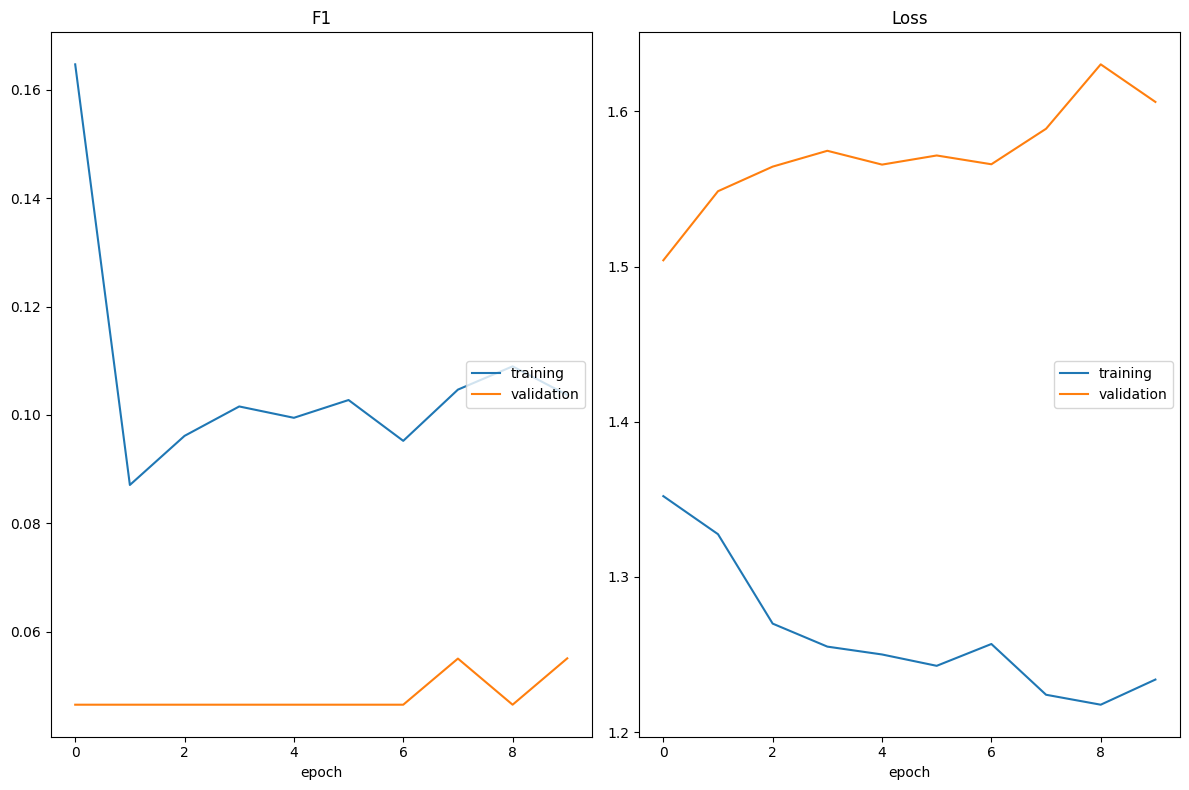

Ep  10/10  loss=1.2338  val_loss=1.6061  F1=0.1037  val_F1=0.0551  AUC=0.5340
  ✔ Melhor modelo guardado (val F1=0.0551)
Fase concluída – melhor val F1: 0.0551
Tempo fase 1: 225.3s


In [22]:
set_seed(SEED)
model      = build_model(freeze_backbone=True)
model_name = get_versioned_model_name(f'{model_path}/mobilenet_v3_best.pth')

opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=1e-4
)
# OneCycleLR converge mais rápido na fase 1
sch1 = torch.optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=LR_P1,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_P1
)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt1, sch1, EPOCHS_P1, model_name,
            patience=PATIENCE, use_mixup=False,
            phase_name='Fase1_FeatureExtraction')
print(f'Tempo fase 1: {time.perf_counter()-t0:.1f}s')

## Treino – Fase 2: Fine-tuning completo + Mixup

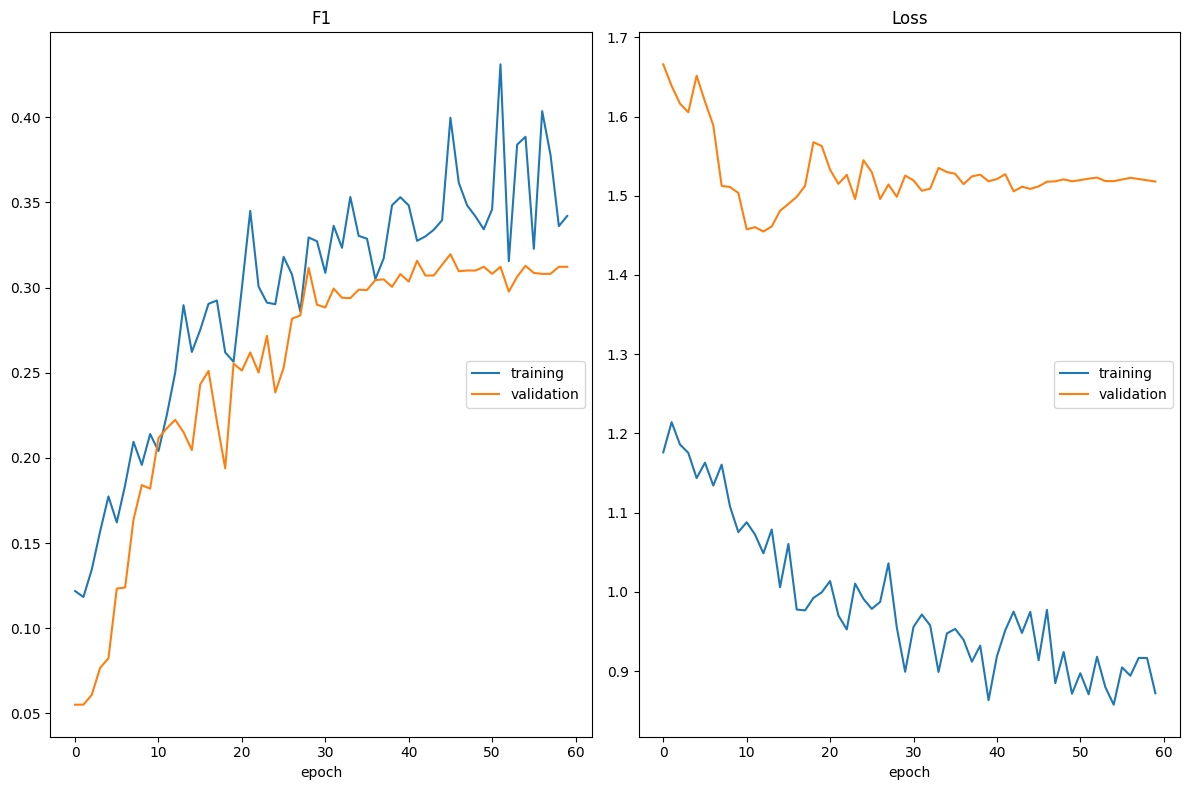

Ep  60/60  loss=0.8720  val_loss=1.5180  F1=0.3421  val_F1=0.3122  AUC=0.6396
Fase concluída – melhor val F1: 0.3196
Tempo fase 2: 1348.8s


In [23]:
model.load_state_dict(torch.load(model_name))
for param in model.parameters():
    param.requires_grad = True
print(f'Backbone descongelado. Parâmetros: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

opt2 = torch.optim.AdamW(model.parameters(), lr=LR_P2, weight_decay=1e-4)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_P2, eta_min=1e-7)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt2, sch2, EPOCHS_P2, model_name,
            patience=PATIENCE, use_mixup=True,
            phase_name='Fase2_FineTuning')
print(f'Tempo fase 2: {time.perf_counter()-t0:.1f}s')

## Avaliação – NOVO: TTA (Test Time Augmentation)

Em vez de uma única predição por imagem, o TTA corre cada imagem `TTA_RUNS` vezes com augmentações ligeiras e faz a média das probabilidades. Melhora o F1 sem retreinar o modelo.

In [24]:
model.load_state_dict(torch.load(model_name))
model.eval()

# ── Avaliação simples (sem TTA) ───────────────────────────────────────────────
all_preds_simple, all_labels_simple, all_probs_simple = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_preds_simple.extend(np.argmax(probs, axis=1))
        all_labels_simple.extend(labels.numpy())
        all_probs_simple.extend(probs)

f1_simple = f1_score(np.array(all_labels_simple), np.array(all_preds_simple), average='macro')
print(f'F1-macro (sem TTA): {f1_simple:.4f}')

# ── Avaliação com TTA ─────────────────────────────────────────────────────────
print(f'\nA correr TTA ({TTA_RUNS} passes)...')
n_test     = len(data['test']['images'])
tta_probs  = np.zeros((n_test, num_class))
all_labels = np.array(data['test']['labels'])

for run in range(TTA_RUNS):
    run_probs = []
    with torch.no_grad():
        for inputs, _ in tta_loader:
            outputs = model(inputs.to(device))
            probs   = F.softmax(outputs, dim=1).cpu().numpy()
            run_probs.extend(probs)
    tta_probs += np.array(run_probs)
    print(f'  TTA pass {run+1}/{TTA_RUNS} OK')

# Adiciona também a predição sem augmentação (pass 0)
tta_probs += np.array(all_probs_simple)
tta_probs /= (TTA_RUNS + 1)

all_preds_tta = np.argmax(tta_probs, axis=1)
f1_tta  = f1_score(all_labels, all_preds_tta, average='macro')
acc_tta = accuracy_score(all_labels, all_preds_tta)

print(f'\n{"="*55}')
print(f' Accuracy (TTA) : {acc_tta:.4f}')
print(f' F1-macro       : {f1_simple:.4f}  →  {f1_tta:.4f}  (com TTA)')
print(f' Baseline artigo: 0.7380')
print(f' Delta vs baseline: {f1_tta-0.738:+.4f}')
print(f'{"="*55}\n')
print(classification_report(all_labels, all_preds_tta,
                             target_names=class_names, digits=4, zero_division=0))

F1-macro (sem TTA): 0.3201

A correr TTA (5 passes)...
  TTA pass 1/5 OK
  TTA pass 2/5 OK
  TTA pass 3/5 OK
  TTA pass 4/5 OK
  TTA pass 5/5 OK

 Accuracy (TTA) : 0.3371
 F1-macro       : 0.3201  →  0.3063  (com TTA)
 Baseline artigo: 0.7380
 Delta vs baseline: -0.4317

               precision    recall  f1-score   support

Biliary_Leaks     0.1897    0.6471    0.2933        17
    Lithiasis     0.0000    0.0000    0.0000       123
       Normal     0.2696    0.7209    0.3924        43
    Stricture     0.5106    0.5714    0.5393        84

     accuracy                         0.3371       267
    macro avg     0.2425    0.4849    0.3063       267
 weighted avg     0.2161    0.3371    0.2515       267



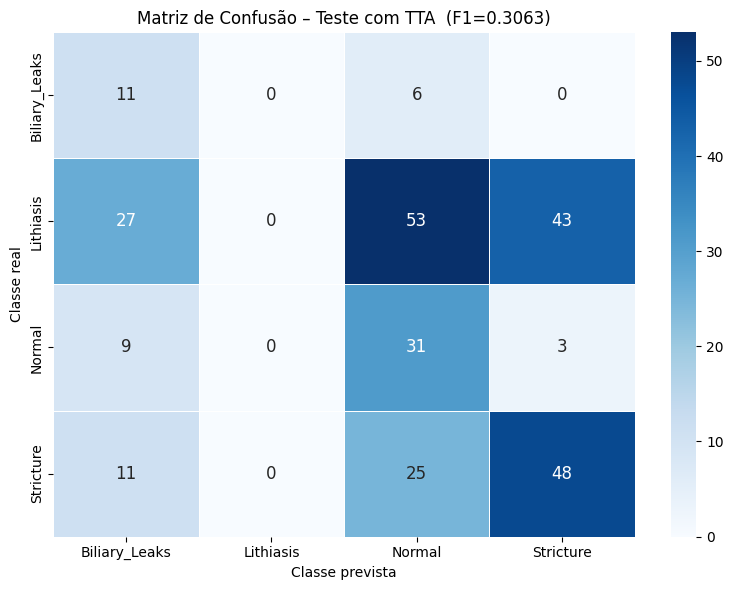

In [25]:
cm = confusion_matrix(all_labels, all_preds_tta)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real'); plt.xlabel('Classe prevista')
plt.title(f'Matriz de Confusão – Teste com TTA  (F1={f1_tta:.4f})')
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix_tta.png', dpi=200)
plt.show()

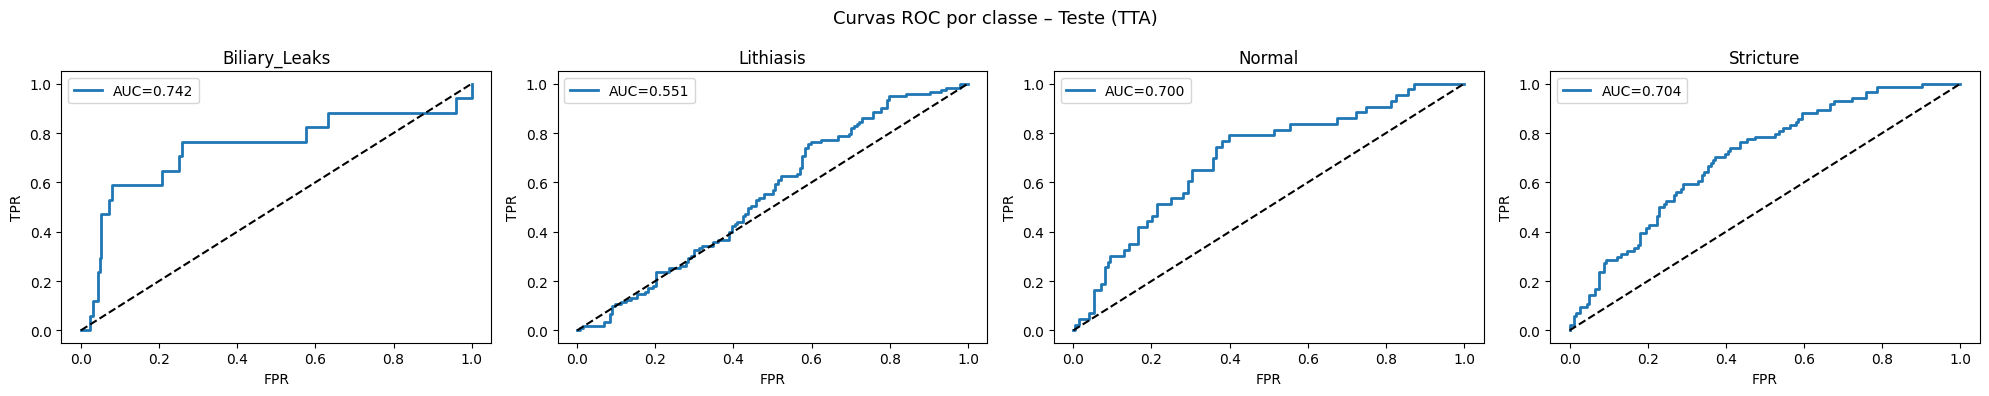

AUC-ROC macro (OvR): 0.6742


In [26]:
y_bin = label_binarize(all_labels, classes=np.arange(num_class))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], tta_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], tta_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--'); ax.set_title(cname)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.suptitle('Curvas ROC por classe – Teste (TTA)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()
mean_auc = roc_auc_score(y_bin, tta_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

## Grad-CAM

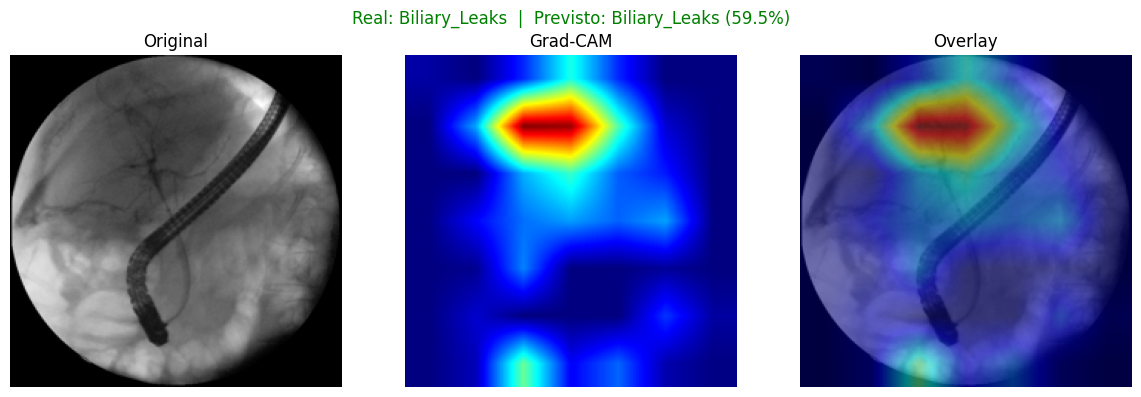

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


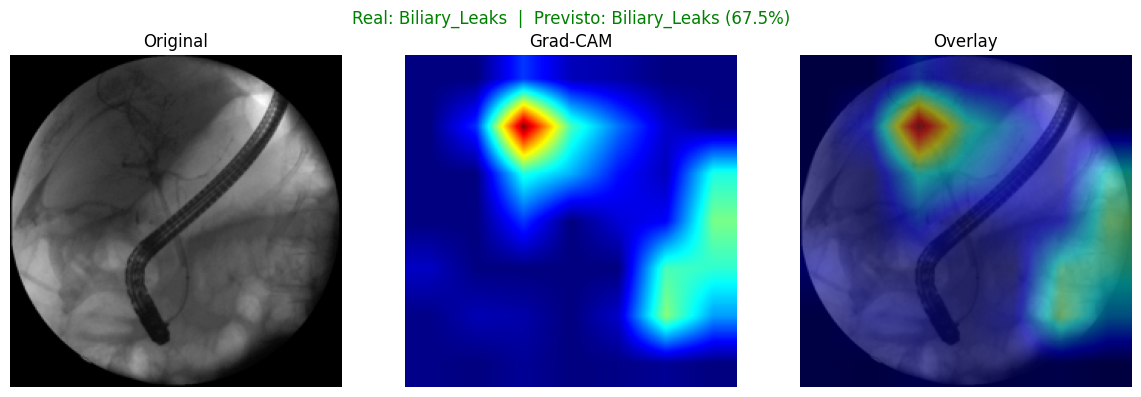

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


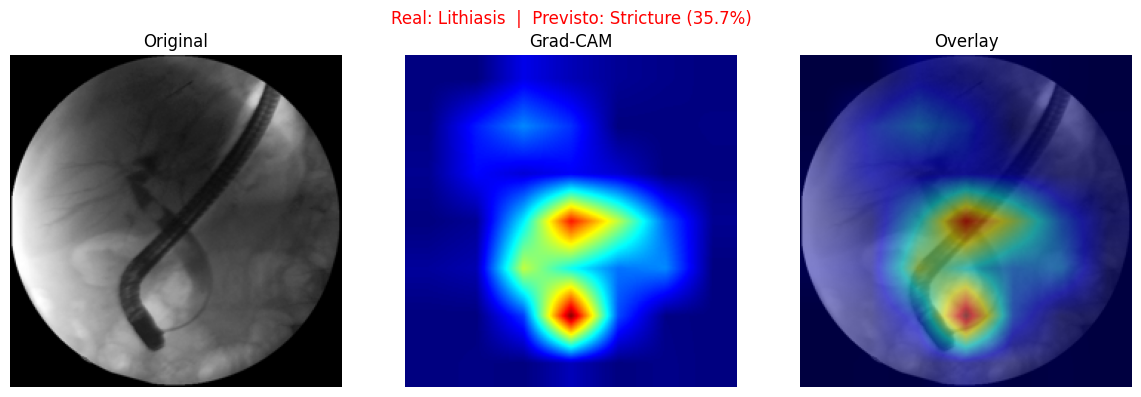

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


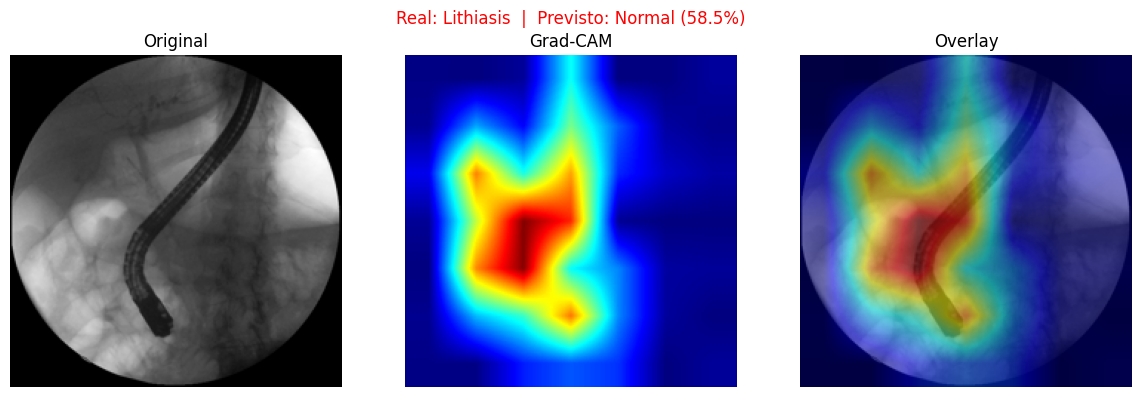

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


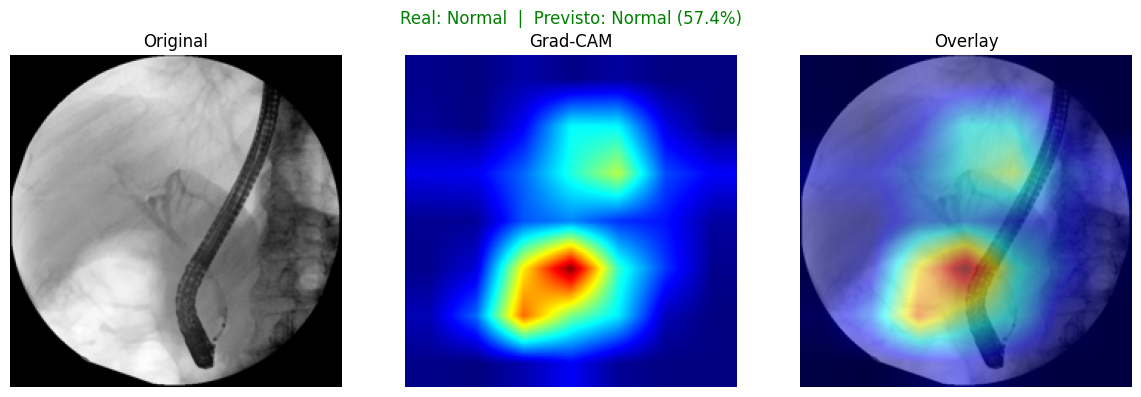

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


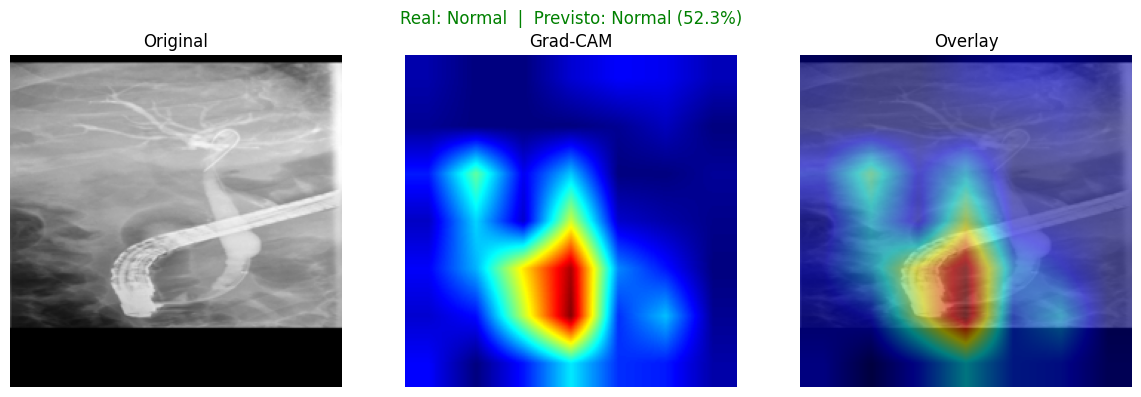

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


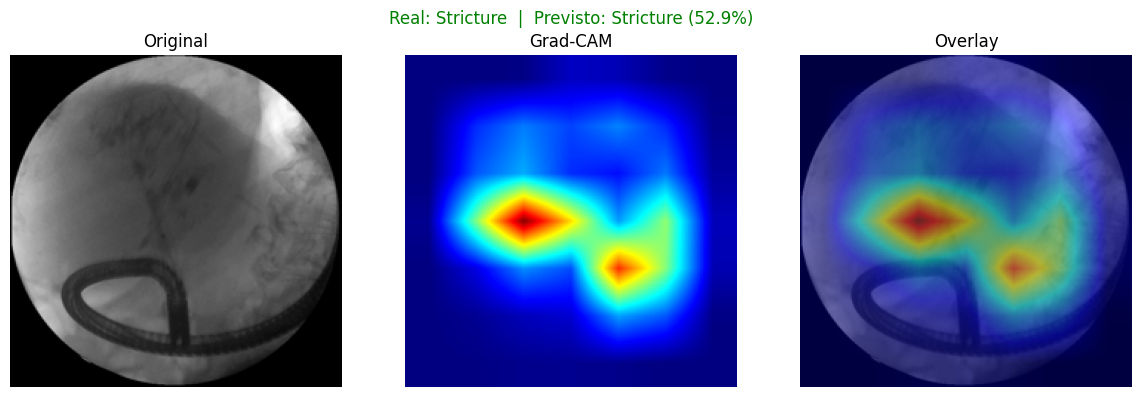

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


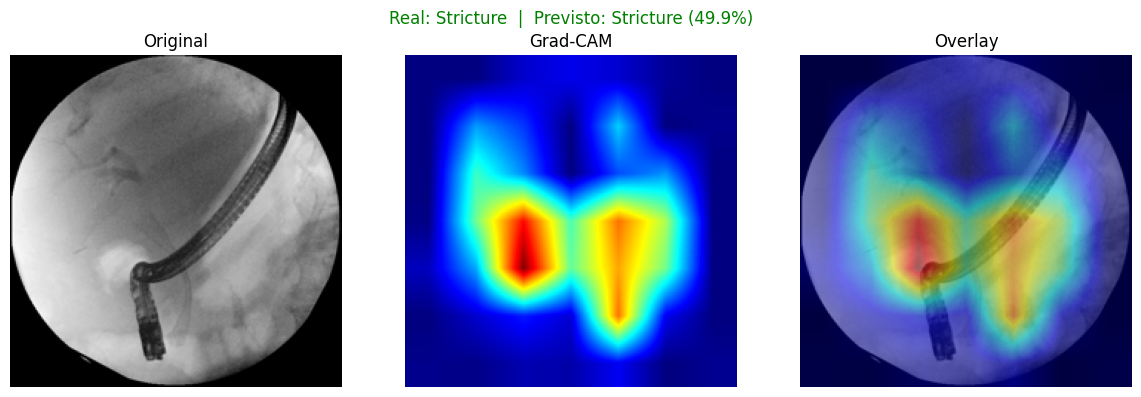

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [27]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x   = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, F.softmax(out, dim=1)[0, class_idx].item()


# MobileNetV3 – última camada convolucional
gradcam = GradCAM(model, target_layer=model.features[-1])

def show_gradcam(img_path, true_label, save_path=None):
    img_tensor = val_transforms(img_path)
    cam, pred_idx, prob = gradcam.generate(img_tensor)
    raw     = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*raw_rgb + 0.5*heatmap).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
                 fontsize=12, color=cor)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(p,l) for p,l in zip(data['test']['images'], data['test']['labels']) if l == ci]
    for k, (path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

In [28]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v0 (professor)   test F1 = 0.4564')
print(f'  v1               test F1 = 0.4973')
print(f'  v2 (sem TTA)     test F1 = {f1_simple:.4f}')
print(f'  v2 (com TTA)     test F1 = {f1_tta:.4f}')
print(f'  Baseline artigo          = 0.7380')
print(f'  Delta vs baseline        = {f1_tta-0.738:+.4f}')
print('='*60)

RESUMO COMPARATIVO
  v0 (professor)   test F1 = 0.4564
  v1               test F1 = 0.4973
  v2 (sem TTA)     test F1 = 0.3201
  v2 (com TTA)     test F1 = 0.3063
  Baseline artigo          = 0.7380
  Delta vs baseline        = -0.4317
